# Phase 3 - Machine Learning Models

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data from Phase 2

In [4]:
# Load Phase 2 output (all 3 outcomes included)
df = pd.read_csv("../data/processed/modeling_dataset_phase3.csv")
df["date"] = pd.to_datetime(df["date"])

# Encode target
outcome_map = {"home_win": 1, "draw": 0, "away_win": -1}
df["outcome"] = df["result"].map(outcome_map)

print("Unmapped rows:", df["outcome"].isna().sum())
print("\nOutcome distribution:")
print(df["outcome"].value_counts().sort_index())
print("\nAs percentages:")
print(df["outcome"].value_counts(normalize=True).mul(100).round(2).sort_index())

display(df.head())

Unmapped rows: 0

Outcome distribution:
outcome
-1     6654
 0     5683
 1    11428
Name: count, dtype: int64

As percentages:
outcome
-1    28.00
 0    23.91
 1    48.09
Name: proportion, dtype: float64


,date,home_team,away_team,neutral,rank_diff,points_diff,form_diff_5,result,outcome
0,1993-01-28,Cameroon,Finland,True,22.0,12.0,-0.666667,home_win,1
1,1993-01-30,India,Cameroon,False,-121.0,-41.0,-1.166667,draw,0
2,1993-02-26,Algeria,Ghana,False,9.0,5.0,-0.266667,home_win,1
3,1993-03-07,Honduras,Costa Rica,False,-3.0,-3.0,-3.000000,home_win,1
4,1993-03-09,Honduras,El Salvador,False,10.0,4.0,1.166667,home_win,1


## Feature Engineer

Features being built:
- `rank_diff` and `points_diff` → already in dataset from Phase 2
- `neutral` → already in dataset from Phase 2
- `avg_goals_scored_5` → rolling avg goals scored (last 5 matches)
- `avg_goals_conceded_5` → rolling avg goals conceded (last 5 matches)
- `recent_win_rate_5` → win rate in last 5 matches

All rolling features use shift(1) to prevent data leakage.

In [5]:
# Step 1: Load raw match history and build a team-level table 
raw = pd.read_csv("../data/processed/results_cleaned.csv")
raw["date"] = pd.to_datetime(raw["date"])

# Each match becomes two rows: one for home team, one for away team
home_side = raw[["date", "home_team", "home_score", "away_score"]].copy()
home_side.columns = ["date", "team", "goals_for", "goals_against"]

away_side = raw[["date", "away_team", "away_score", "home_score"]].copy()
away_side.columns = ["date", "team", "goals_for", "goals_against"]

# Combine home and away sides
team_hist = pd.concat([home_side, away_side], ignore_index=True)
team_hist = team_hist.sort_values(["team", "date"]).reset_index(drop=True)

# Win = 1 if the team scored more foals than the opponent
team_hist["win"] = (team_hist["goals_for"] > team_hist["goals_against"]).astype(int)

print("Team History shape: ", team_hist.shape)
display(team_hist.head(8))

Team History shape:  (48368, 5)


,date,team,goals_for,goals_against,win
0,2003-03-18,Afghanistan,0,4,0
1,2003-11-19,Afghanistan,0,11,0
2,2003-11-23,Afghanistan,0,2,0
3,2005-11-09,Afghanistan,0,4,0
4,2005-12-07,Afghanistan,1,9,0
5,2005-12-09,Afghanistan,0,1,0
6,2005-12-11,Afghanistan,2,1,1
7,2006-04-05,Afghanistan,1,1,0


In [6]:
# Step 2: Build rolling features (last 5 matches, no leakage)
def rolling_mean(series):
    return series.shift(1).rolling(5, min_periods=3).mean()

team_hist["avg_goals_scored_5"] = team_hist.groupby("team")["goals_for"].transform(rolling_mean)
team_hist["avg_goals_conceded_5"] = team_hist.groupby("team")["goals_against"].transform(rolling_mean)
team_hist["recent_win_rate_5"] = team_hist.groupby("team")["win"].transform(rolling_mean)

display(team_hist[["date", "team", "avg_goals_scored_5", "avg_goals_conceded_5", "recent_win_rate_5"]].head(12))

,date,team,avg_goals_scored_5,avg_goals_conceded_5,recent_win_rate_5
0,2003-03-18,Afghanistan,NaN,NaN,NaN
1,2003-11-19,Afghanistan,NaN,NaN,NaN
2,2003-11-23,Afghanistan,NaN,NaN,NaN
3,2005-11-09,Afghanistan,0.0,5.666667,0.0
4,2005-12-07,Afghanistan,0.0,5.250000,0.0
5,2005-12-09,Afghanistan,0.2,6.000000,0.0
6,2005-12-11,Afghanistan,0.2,5.400000,0.0
7,2006-04-05,Afghanistan,0.6,3.400000,0.2
8,2007-10-08,Afghanistan,0.8,3.200000,0.2
9,2007-10-26,Afghanistan,0.8,3.000000,0.2


In [7]:
# Step 3: Merge features back into the ,atch level dataset
feats = team_hist[["date", "team", "avg_goals_scored_5", "avg_goals_conceded_5", "recent_win_rate_5"]]

# Attach home team features
df = df.merge( feats.rename(columns={
    "team": "home_team",
    "avg_goals_scored_5": "home_avg_goals_scored_5",
    "avg_goals_conceded_5": "home_avg_goals_conceded_5",
    "recent_win_rate_5": "home_recent_win_rate_5"
}), on=["date", "home_team"], how="left")
# Attach away team features
df = df.merge( feats.rename(columns={
    "team": "away_team",
    "avg_goals_scored_5": "away_avg_goals_scored_5",
    "avg_goals_conceded_5": "away_avg_goals_conceded_5",
    "recent_win_rate_5": "away_recent_win_rate_5"
}), on=["date", "away_team"], how="left")

# Difference features: postive = home team is stronger
df["avg_gf_diff"] = df["home_avg_goals_scored_5"] - df["away_avg_goals_scored_5"]
df["avg_ga_diff"] = df["home_avg_goals_conceded_5"] - df["away_avg_goals_conceded_5"]
df["win_rate_diff"] = df["home_recent_win_rate_5"] - df["away_recent_win_rate_5"]
df["is_neutral"] = df["neutral"].astype(int)

print("Shape after merge:", df.shape)
print("\nMissing values in new features:")
print(df[["avg_gf_diff", "avg_ga_diff", "win_rate_diff"]].isna().sum())

display(df[["date", "home_team", "away_team",
            "rank_diff", "avg_gf_diff", "avg_ga_diff", "win_rate_diff", "is_neutral", "outcome"]].head(10))

Shape after merge: (23793, 19)

Missing values in new features:
avg_gf_diff      0
avg_ga_diff      0
win_rate_diff    0
dtype: int64


,date,home_team,away_team,rank_diff,avg_gf_diff,avg_ga_diff,win_rate_diff,is_neutral,outcome
0,1993-01-28,Cameroon,Finland,22.0,-0.333333,0.333333,-0.333333,1,1
1,1993-01-30,India,Cameroon,-121.0,-0.416667,0.750000,-0.250000,0,0
2,1993-02-26,Algeria,Ghana,9.0,-0.200000,0.066667,-0.133333,0,1
3,1993-03-07,Honduras,Costa Rica,-3.0,-1.666667,1.333333,-0.666667,0,1
4,1993-03-09,Honduras,El Salvador,10.0,0.833333,-0.333333,0.500000,0,1
5,1993-03-12,El Salvador,Bolivia,37.0,-0.833333,0.416667,-0.333333,0,0
6,1993-03-14,Honduras,Bolivia,47.0,0.300000,-0.700000,0.350000,0,0
7,1993-03-16,Honduras,Bolivia,47.0,0.400000,-0.600000,0.400000,0,0
8,1993-03-31,Poland,Lithuania,73.0,0.000000,-2.333333,-0.333333,0,0
9,1993-04-04,El Salvador,Mexico,-25.0,0.466667,0.133333,0.000000,0,1


In [8]:
# Step 4: Keep only rows where ALL features are present
feature_cols = ["rank_diff", "points_diff", "form_diff_5", "avg_gf_diff", "avg_ga_diff", "win_rate_diff", "is_neutral"]

df_model = df.dropna(subset=feature_cols + ["outcome"]).copy().reset_index(drop=True)

print("Rows available for modeling:", len(df_model))
print("\nOutcome distribution in modeling dataset:")
print(df_model["outcome"].value_counts().sort_index())
print("\nAs percentages:")
print(df_model["outcome"].value_counts(normalize=True).mul(100).round(2).sort_index())

Rows available for modeling: 23793

Outcome distribution in modeling dataset:
outcome
-1     6658
 0     5685
 1    11450
Name: count, dtype: int64

As percentages:
outcome
-1    27.98
 0    23.89
 1    48.12
Name: proportion, dtype: float64


## Train/Test Split by Year
Why split by year, not randomly?

If you split randomly, a match from 2010 could end up in your training set using form features built from 2012 matches. That is data leakage — the model would be learning from the future.

Splitting by year guarantees:

training data = everything before the split year
test data = everything from the split year onwards

This simulates a real scenario: "I trained on historical data, now I predict future matches."

In [9]:
# Checking match counts per year to pick a good split point
year_counts = df_model['date'].dt.year.value_counts().sort_index()
print(year_counts)
print("\nTotal matches:", len(df_model))
print("Cumulative % by year:")
print((year_counts.cumsum() / len(df_model) * 100).round(1))

date
1993     328
1994     411
1995     502
1996     659
1997     704
1998     576
1999     615
2000     841
2001     831
2002     608
2003     744
2004     876
2005     639
2006     648
2007     797
2008     884
2009     737
2010     698
2011     884
2012     809
2013     805
2014     661
2015     788
2016     717
2017     706
2018     723
2019     874
2020     313
2021     975
2022     795
2023     813
2024    1001
2025     813
2026      18
Name: count, dtype: int64

Total matches: 23793
Cumulative % by year:
date
1993      1.4
1994      3.1
1995      5.2
1996      8.0
1997     10.9
1998     13.4
1999     16.0
2000     19.5
2001     23.0
2002     25.5
2003     28.7
2004     32.3
2005     35.0
2006     37.8
2007     41.1
2008     44.8
2009     47.9
2010     50.8
2011     54.6
2012     58.0
2013     61.3
2014     64.1
2015     67.4
2016     70.4
2017     73.4
2018     76.5
2019     80.1
2020     81.4
2021     85.5
2022     88.9
2023     92.3
2024     96.5
2025     99.9
2026    100.0
Na

## Split year = 2019
- Why not 2018: 
    - 73.4% train is a bit low. Also 2018 is a World Cup year — better to have it in the test set so the model is evaluated on World Cup-era matches.
- Why 2019: 
    - 76.5% train is close enough to 80/20
    - Test set covers 2019–2026 (7 years including the 2022 World Cup and the upcoming 2026 WC)
    - 2019 was a normal year (874 matches), clean boundary
    - Both World Cups (2022 and 2026) are in the test set — exactly what Phase 4 simulation needs

In [10]:
# Split year chosen: 2019
# Train matches: 1993 - 2018 (76.5%) 
# Test matches: 2019 - 2022 (23.5%)

SPLIT_YEAR = 2019

train = df_model[df_model["date"].dt.year < SPLIT_YEAR].copy()
test = df_model[df_model["date"].dt.year >= SPLIT_YEAR].copy()

print(f"Train: {len(train)} matches ({len(train)/len(df_model)*100:.1f}%)")
print(f"Test: {len(test)} matches ({len(test)/len(df_model)*100:.1f}%)")

print("\nTrain outcome distribution (in %):")
print(train['outcome'].value_counts(normalize=True).mul(100).round(2).sort_index())

print("\nTest outcome distribution (in %):")
print(test['outcome'].value_counts(normalize=True).mul(100).round(2).sort_index())



Train: 18191 matches (76.5%)
Test: 5602 matches (23.5%)

Train outcome distribution (in %):
outcome
-1    27.48
 0    24.02
 1    48.50
Name: proportion, dtype: float64

Test outcome distribution (in %):
outcome
-1    29.61
 0    23.49
 1    46.89
Name: proportion, dtype: float64


In [11]:
# Defining X (features) and y (target) for train and test
# X = what the model sees to make a prediction
# y = what the model is trying to predict --> outcome (1(win), 0(draw), -1(loss))

feature_cols = [
    "rank_diff",          # FIFA ranking difference (home - away)
    "points_diff",        # FIFA points difference
    "form_diff_5",        # Recent goal-difference form (last 5 matches)
    "avg_gf_diff",        # Average goals scored difference (last 5 matches)
    "avg_ga_diff",        # Average goals conceded difference (last 5 matches)
    "win_rate_diff",      # Recent win rate difference (last 5 matches)
    "is_neutral"         # Whether the match is on neutral ground (1) or not (0)
]

X_train = train[feature_cols]
y_train = train["outcome"]

X_test = test[feature_cols]
y_test = test["outcome"]

print("X_train shape:", X_train.shape)

print("X_test shape:", X_test.shape)

print("\nFeature columns:", feature_cols)

X_train shape: (18191, 7)
X_test shape: (5602, 7)

Feature columns: ['rank_diff', 'points_diff', 'form_diff_5', 'avg_gf_diff', 'avg_ga_diff', 'win_rate_diff', 'is_neutral']


# Model 1: Logistic Regression
### Why start here?
- easy to interpret (you can see which features matter most)
- fast to train
- gives probability estimates per class (needed for Phase 4 simulation)
- acts as a baseline — if complex models can't beat it, something is wrong

**Key idea:** Logistic Regression is sensitive to feature scale, so features
are standardized first (mean=0, std=1). The scaler is fitted on train only
to avoid leaking test statistics.

Scalling done.
Model training completed.
=== Logistic Regression Results ===
Accuracy: 0.5750 (57.50%)
Log Loss: 0.9048


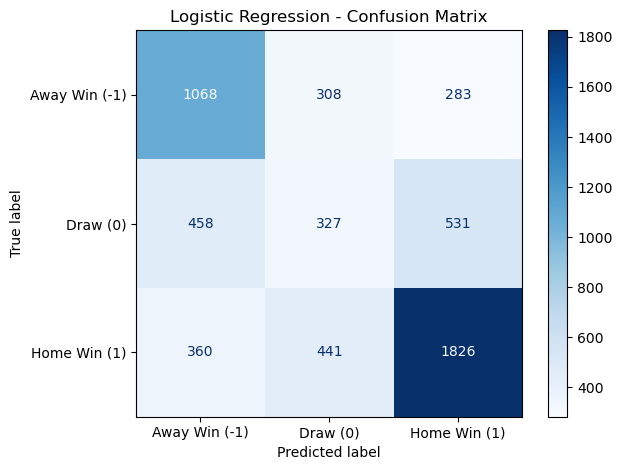

Feature coefficients (Logistic Regression):


,rank_diff,points_diff,form_diff_5,avg_gf_diff,avg_ga_diff,win_rate_diff,is_neutral
away_win (-1),-0.5360,-0.1111,-0.1119,-0.0571,0.1227,0.0806,0.1647
draw (0),-0.0637,0.0420,-0.0038,-0.0051,0.0013,0.0126,-0.0254
home_win (1),0.5997,0.0691,0.1157,0.0622,-0.1241,-0.0931,-0.1393


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Scale features
# Fit ONLY on training data, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scalling done.")

# Step 2: Train the model
# class_weight = "balanced" adjusts for the class imbalance (~48% home wins, ~24% draws, ~28% away wins)
# max_itera = 1000 gives the solver enough iterations to converge

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print("Model training completed.")

# Step 3: Evaluate on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_logloss = log_loss(y_test, y_proba_lr)

print("=== Logistic Regression Results ===")
print(f"Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Log Loss: {lr_logloss:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr, labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Away Win (-1)", "Draw (0)", "Home Win (1)"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 4: Feature importance (coefficients)
# Each row = one class, each column = one feature
# Larger absolute value = stronger influence on predicting that class

coef_df = pd.DataFrame(
    lr_model.coef_,
    columns=feature_cols,
    index=["away_win (-1)", "draw (0)", "home_win (1)"]
)

print("Feature coefficients (Logistic Regression):")
display(coef_df.round(4))


### Logistic Regression - Summary and Key Findings

**Results:**
- Accuracy: **57.50%** — well above a random 3-class baseline of ~33%, showing the model is learning real patterns.
- Log Loss: **0.9048** — this is the benchmark to beat with more complex models. Lower is better.

**Confusion matrix observations:**
- Home wins are predicted best (1826 correct out of 2627).
- Draws are the hardest to predict — only 327 correct out of 1316. The model often confuses draws with home wins or away wins, which makes sense since draws are the most unpredictable outcome in soccer.
- Away wins are reasonably predicted (1068 correct out of 1659), but many are misclassified as draws or home wins.

**Feature coefficients:**
- `rank_diff` is the most influential feature by far — a positive rank_diff strongly pushes the prediction toward home_win and away from away_win. This aligns with what was found in Phase 2.
- `is_neutral` reduces the home_win probability (negative coefficient), which also makes sense — removing home advantage on neutral sites lowers the home team's edge.
- Recent form features (`form_diff_5`, `avg_gf_diff`, `win_rate_diff`) all have the expected direction but smaller magnitudes, confirming they add signal but are secondary to rankings.

**Limitations of this model:**
- Logistic Regression assumes a linear relationship between features and outcome. Soccer outcomes may have nonlinear patterns that this model cannot capture.
- Draws remain difficult for any model — this is a known challenge in soccer prediction.

**Next step:** Train Random Forest to capture nonlinear relationships and compare results.

# Model 2: Random Forest
### Why? 
- Key advantages over Logistic Regression: 
    - captures nonlinear relationships — rankings may interact with form in complex ways
    - naturally handles features of different scales — no scaling needed
    - gives feature importance scores (different from coefficients — more intuitive)
    - still gives probability estimates for Phase 4

**Key parameters to understand:**
- `n_estimators`: number of trees — more trees = more stable but slower
- `max_depth`: how deep each tree can grow — limits overfitting
- `class_weight='balanced'`: compensates for class imbalance, same as Model 1
- `random_state=42`: ensures reproducibility

Random Forest training completed.
=== Random Forest Results ===
Accuracy: 0.5650 (56.50%)
Log Loss: 0.9077


=== Comparison so far ===
Logistic Regression --> Accuracy: 0.57%, Log Loss: 0.9048
Random Forest       --> Accuracy: 0.56%, Log Loss: 0.9077


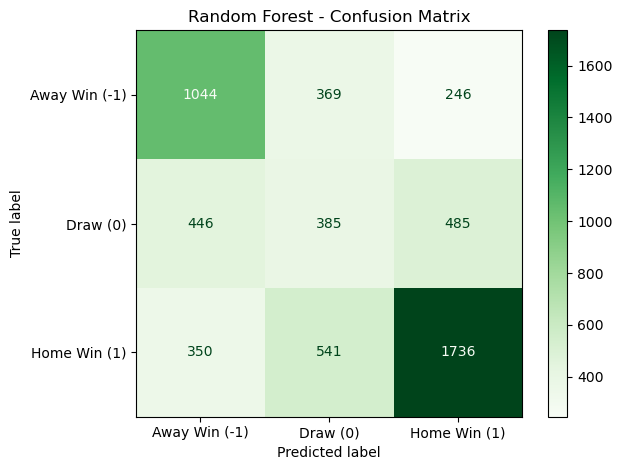

Feature Importances (Random Forest):


,feature,importance
0,rank_diff,0.3684
1,points_diff,0.2768
2,form_diff_5,0.1228
3,avg_ga_diff,0.0966
4,avg_gf_diff,0.0560
5,win_rate_diff,0.0427
6,is_neutral,0.0368


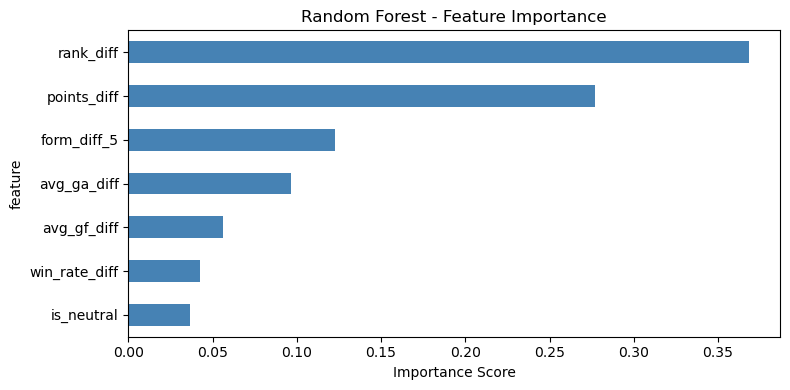

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 300,        # 300 trees - good balance of speed and stability
    max_depth=8,               # Reduce overfitting
    class_weight="balanced",   # Adjust for class imbalance
    random_state=42, 
    n_jobs=-1                 # Use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

# Evaluate on test set. 
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

# Normalize probabilities to fix floating-point rounding errors
# Each row should sum to exactly 1.0 for log_loss to work correctly
y_proba_rf = y_proba_rf / y_proba_rf.sum(axis=1, keepdims=True)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_logloss = log_loss(y_test, y_proba_rf)

print("=== Random Forest Results ===")
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Log Loss: {rf_logloss:.4f}")

# Compare directly with Linear Regression
print("\n\n=== Comparison so far ===")
print(f"Logistic Regression --> Accuracy: {lr_accuracy:.2f}%, Log Loss: {lr_logloss:.4f}")
print(f"Random Forest       --> Accuracy: {rf_accuracy:.2f}%, Log Loss: {rf_logloss:.4f}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 0, 1])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Away Win (-1)", "Draw (0)", "Home Win (1)"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance
# Unlike coefficients, importance = how much each feature reduces prediction error across all trees
# Higher value = more useful feature overall

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importances (Random Forest):")
display(importance_df.round(4))

# Bar chart
importance_df.plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 4),
    legend=False,
    color="steelblue"
)
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Random Forest - Summary and Key Findings

**Results:**
- Accuracy: **56.50%** — slightly below Logistic Regression (57.50%). A more complex model did not automatically win.
- Log Loss: **0.9077** — marginally worse than LR's 0.9048. This means the RF's probability estimates are slightly less calibrated, even though both models perform similarly overall.

**Confusion matrix observations:**
- Home wins remain the easiest class (1736 correct out of 2627) — both models agree here.
- Draws are still the hardest (385 correct out of 1316) — RF actually improved slightly over LR's 327, but draws remain poorly predicted across the board.
- Away wins: 1044 correct out of 1659 — comparable to LR.

**Feature importance:**
- `rank_diff` (37%) and `points_diff` (28%) dominate — together they account for ~65% of the model's decision-making power. FIFA rankings are the strongest signal.
- `form_diff_5` (12%) is a meaningful third contributor — recent form adds value beyond just rankings.
- Goal-based features (`avg_ga_diff`, `avg_gf_diff`) contribute modestly.
- `is_neutral` and `win_rate_diff` are the least important — this is consistent with LR coefficients.

**Why didn't RF beat LR?**
- Soccer outcomes contain a lot of inherent randomness — no model captures it all.
- With only 7 features, there isn't much nonlinearity for RF to exploit over LR.
- Both models are essentially bottlenecked by the same information. XGBoost may squeeze out more through gradient boosting.

**Next step:** Train XGBoost (Model 3) — a boosting approach that builds trees sequentially, each correcting the errors of the previous one.

# Model 3: XGBoost
### Why?
- **Boosting** vs bagging (Random Forest): instead of building trees independently in parallel, XGBoost builds them **sequentially** — each tree corrects the errors of the previous one.
- Often achieves better performance than RF on tabular data with the same features.
- Still gives probability estimates per class for Phase 4.

**Key parameters:**
- `n_estimators`: number of boosting rounds (trees)
- `max_depth`: max depth per tree — lower = less overfitting
- `learning_rate`: how much each tree contributes — lower = more conservative, needs more trees
- `eval_metric='mlogloss'`: optimizes log loss directly (multi-class version)
- `use_label_encoder=False`: suppresses a deprecation warning

> **Important:** XGBoost requires integer class labels starting from 0.  
> Our outcome labels are `-1, 0, 1` — so we remap them to `0, 1, 2` before training and back for display.

XGBoost training completed.
=== XGBoost Results ===
Accuracy: 0.5918 (59.18%)
Log Loss: 0.8883


=== Comparison so far ===
Logistic Regression --> Accuracy: 0.57%, Log Loss: 0.9048
Random Forest       --> Accuracy: 0.56%, Log Loss: 0.9077
XGBoost             --> Accuracy: 0.59%, Log Loss: 0.8883


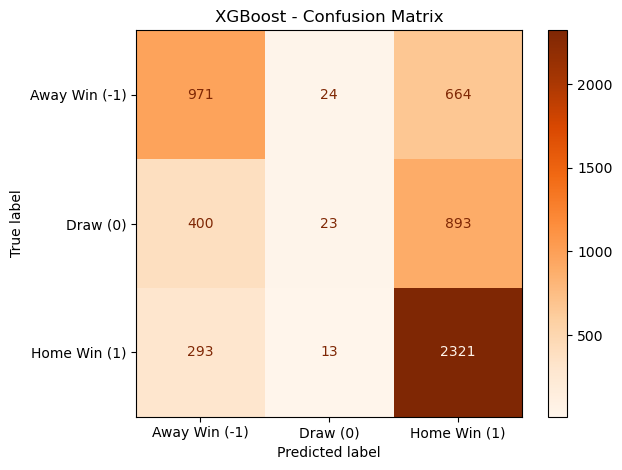

Feature Importances (XGBoost):


,feature,importance
0,rank_diff,0.3673
1,points_diff,0.2151
2,is_neutral,0.1686
3,form_diff_5,0.0783
4,avg_ga_diff,0.0634
5,win_rate_diff,0.0539
6,avg_gf_diff,0.0534


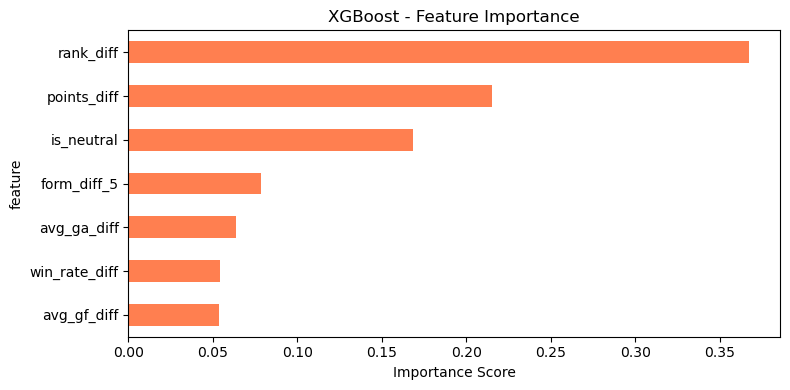

In [15]:
from xgboost import XGBClassifier

# XGBoost requires class labels 0,1,2 instead of -1,0,1
label_map = {-1: 0, 0: 1, 1: 2}
label_map_inv = {0: -1, 1: 0, 2: 1}

y_train_xgb = y_train.map(label_map)
y_test_xgb = y_test.map(label_map)

# Train the Model
xgb_model = XGBClassifier(
    n_estimators=300,        # Number of trees
    max_depth=5,            # Max depth of each tree
    learning_rate=0.05,      # Step size shrinkage
    eval_metric="mlogloss",  # Multi-class log loss
    random_state=42, 
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_xgb)
print("XGBoost training completed.")

# Evaluate on test set
y_pred_xgb_mapped = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)

# Normalize probabilities to ensure they sum to 1 for log_loss
y_proba_xgb = y_proba_xgb / y_proba_xgb.sum(axis=1, keepdims=True)

# Remap predictions back to -1, 0, 1 for evaluation
y_pred_xgb = pd.Series(y_pred_xgb_mapped).map(label_map_inv).values

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_logloss = log_loss(y_test_xgb, y_proba_xgb)

print("=== XGBoost Results ===")
print(f"Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"Log Loss: {xgb_logloss:.4f}")

# Comparison so far
print("\n\n=== Comparison so far ===")
print(f"Logistic Regression --> Accuracy: {lr_accuracy:.2f}%, Log Loss: {lr_logloss:.4f}")
print(f"Random Forest       --> Accuracy: {rf_accuracy:.2f}%, Log Loss: {rf_logloss:.4f}")
print(f"XGBoost             --> Accuracy: {xgb_accuracy:.2f}%, Log Loss: {xgb_logloss:.4f}")

# Confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[-1, 0, 1])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Away Win (-1)", "Draw (0)", "Home Win (1)"])
disp_xgb.plot(cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance for XGBoost
xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importances (XGBoost):")
display(xgb_importance_df.round(4))

# Bar chart for XGBoost feature importance
xgb_importance_df.plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 4),
    legend=False,
    color="coral"
)
plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## XGBoost - Summary and Key Findings

**Results:**
- Accuracy: **59.18%** — the best of the three models, beating LR (57.50%) and RF (56.50%).
- Log Loss: **0.8883** — also the best, meaning XGBoost produces the most well-calibrated probabilities. This is the model we'll use for Phase 4.

**Confusion matrix observations:**
- Home wins: 2321 correct out of 2627 — noticeably better than LR (1826) and RF (1736).
- Draws: only 23 correct out of 1316 — XGBoost essentially stopped predicting draws at all. It found that confidently predicting home/away wins gave lower overall log loss than guessing draws.
- Away wins: 971 correct out of 1659 — lower raw count than LR/RF, but XGBoost compensates by being more confident when it does predict them.

**Feature importance — notable difference from RF:**
- `rank_diff` (37%) and `points_diff` (22%) still lead, consistent with all models.
- `is_neutral` jumped to 3rd place (17%) — XGBoost learned that neutral venue is a stronger signal than form when boosting corrections are applied. LR and RF ranked it last.
- `form_diff_5` drops to 4th — still useful, but less dominant than in RF.

**Why did XGBoost win?**
- Boosting iteratively focuses on misclassified matches — it keeps correcting hard cases that RF and LR give up on.
- Optimizing `mlogloss` directly aligns the training objective with our evaluation metric.

**Next step:** Build the final model comparison table and select the best model for Phase 4.

## Model Comparison & Best Model Selection

=== Final Model Comparison ===


,Model,Log Loss,Accuracy (%)
0,Logistic Regression,0.9048,57.50%
1,Random Forest,0.9077,56.50%
2,XGBoost,0.8883,59.18%


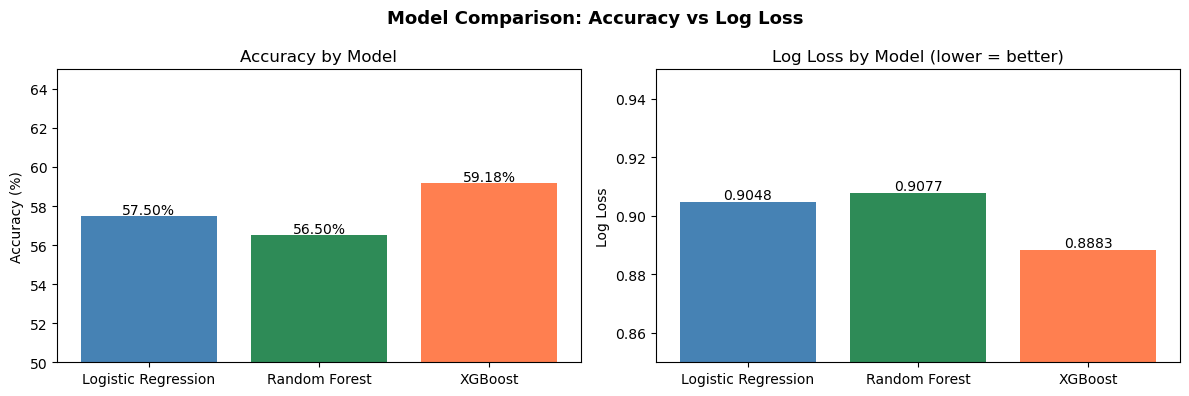

In [20]:
import matplotlib.patches as mpatches

# Build comparison table
comparison_df = pd.DataFrame({
    "Model":    ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_accuracy, rf_accuracy, xgb_accuracy],
    "Log Loss": [lr_logloss, rf_logloss, xgb_logloss]
})

comparison_df["Accuracy (%)"] = (comparison_df["Accuracy"] * 100).round(2)
comparison_df = comparison_df.drop(columns="Accuracy")

# Highlight best value in each column
print("=== Final Model Comparison ===")
display(comparison_df.style
    .highlight_min(subset=["Log Loss"], color="green")
    .highlight_max(subset=["Accuracy (%)"], color="green")
    .format({"Accuracy (%)": "{:.2f}%", "Log Loss": "{:.4f}"})
)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = comparison_df["Model"]

axes[0].bar(models, comparison_df["Accuracy (%)"], color=["steelblue", "seagreen", "coral"])
axes[0].set_title("Accuracy by Model")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(50, 65)
for i, v in enumerate(comparison_df["Accuracy (%)"]):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=10)

axes[1].bar(models, comparison_df["Log Loss"], color=["steelblue", "seagreen", "coral"])
axes[1].set_title("Log Loss by Model (lower = better)")
axes[1].set_ylabel("Log Loss")
axes[1].set_ylim(0.85, 0.95)
for i, v in enumerate(comparison_df["Log Loss"]):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10)

plt.suptitle("Model Comparison: Accuracy vs Log Loss", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Best Model: XGBoost

| Metric | Logistic Regression | Random Forest | XGBoost |
|--------|-------------------|---------------|---------|
| Accuracy | 57.50% | 56.50% | **59.18%** ✅ |
| Log Loss | 0.9048 | 0.9077 | **0.8883** ✅ |

XGBoost wins on both metrics — it is the best model for Phase 4.

---

### Why Log Loss matters more than Accuracy here

**Accuracy** only tells you if the model picked the right winner — it is binary (right or wrong).

**Log Loss** measures how *confident and correct* the probability estimates are. If the model says "70% home win" and the home team wins, that's better than saying "34% home win" and getting lucky.

In Phase 4, we are not just predicting winners — we are **sampling outcomes from probabilities** to simulate 10,000 World Cups. A model with better-calibrated probabilities produces more realistic simulations. That's why a lower log loss is the deciding factor here, not accuracy.

> In short: Accuracy tells you if the model is right. Log Loss tells you if the model *knows* it's right.

**Phase 4 will use:** `xgb_model.predict_proba()` on each matchup to get `[P(away_win), P(draw), P(home_win)]`

In [21]:
import joblib
import os

# Save the best model and the label maps for use in Phase 4
os.makedirs("../outputs", exist_ok=True)

joblib.dump(xgb_model, "../outputs/best_model_xgb.pkl")
joblib.dump(label_map,     "../outputs/label_map.pkl")
joblib.dump(label_map_inv, "../outputs/label_map_inv.pkl")
joblib.dump(feature_cols,  "../outputs/feature_cols.pkl")

print("Saved:")
print("  ../outputs/best_model_xgb.pkl")
print("  ../outputs/label_map.pkl")
print("  ../outputs/label_map_inv.pkl")
print("  ../outputs/feature_cols.pkl")
print("\nPhase 3 complete. Ready for Phase 4 — World Cup simulation.")

Saved:
  ../outputs/best_model_xgb.pkl
  ../outputs/label_map.pkl
  ../outputs/label_map_inv.pkl
  ../outputs/feature_cols.pkl

Phase 3 complete. Ready for Phase 4 — World Cup simulation.
